<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-lab/blob/lab11/lab11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce

df = pd.read_excel("messy_hr_economics_lab11.xlsx")

df.head()

,employee_id,department,performance_rating,years_experience,tenure_years,education_level,remote_days_per_week,office_zip,regional_unemployment,cost_of_living_idx,base_salary,bonus_pay,hourly_contractor_rate,hire_date
0,100000,engineering,Medium,7,7,Bachelors,4,62276,4.09,93.1,72070.02,4065.24,USD 68.47,2016-03-17
1,100001,Sales,Medium,11,1,Masters,4,72044,3.95,94.7,68161.33,5099.66,USD 49.04,2017-04-05
2,100002,Sales,Medium,17,8,Bachelors,2,50544,2.30,99.8,95119.46,5618.26,USD 73.67,2021-11-24
3,100003,Engineering,Medium,8,8,PhD,0,44520,4.46,119.8,76249.59,2880.94,NaN,2014-03-05
4,100004,Engineering,Medium,10,5,Bachelors,5,93647,4.57,88.1,72987.84,5047.55,35.03,2012-11-19


In [8]:

df.dtypes

df.isnull().sum()

,0
employee_id,0
department,0
performance_rating,332
years_experience,0
tenure_years,0
education_level,0
remote_days_per_week,0
office_zip,0
regional_unemployment,0
cost_of_living_idx,0


employee_id                 0
department                  0
performance_rating        332
years_experience            0
tenure_years                0
education_level             0
remote_days_per_week        0
office_zip                  0
regional_unemployment       0
cost_of_living_idx          0
base_salary                 0
bonus_pay                 332
hourly_contractor_rate    459
hire_date                   0
zip_encoded                 0
dtype: int64


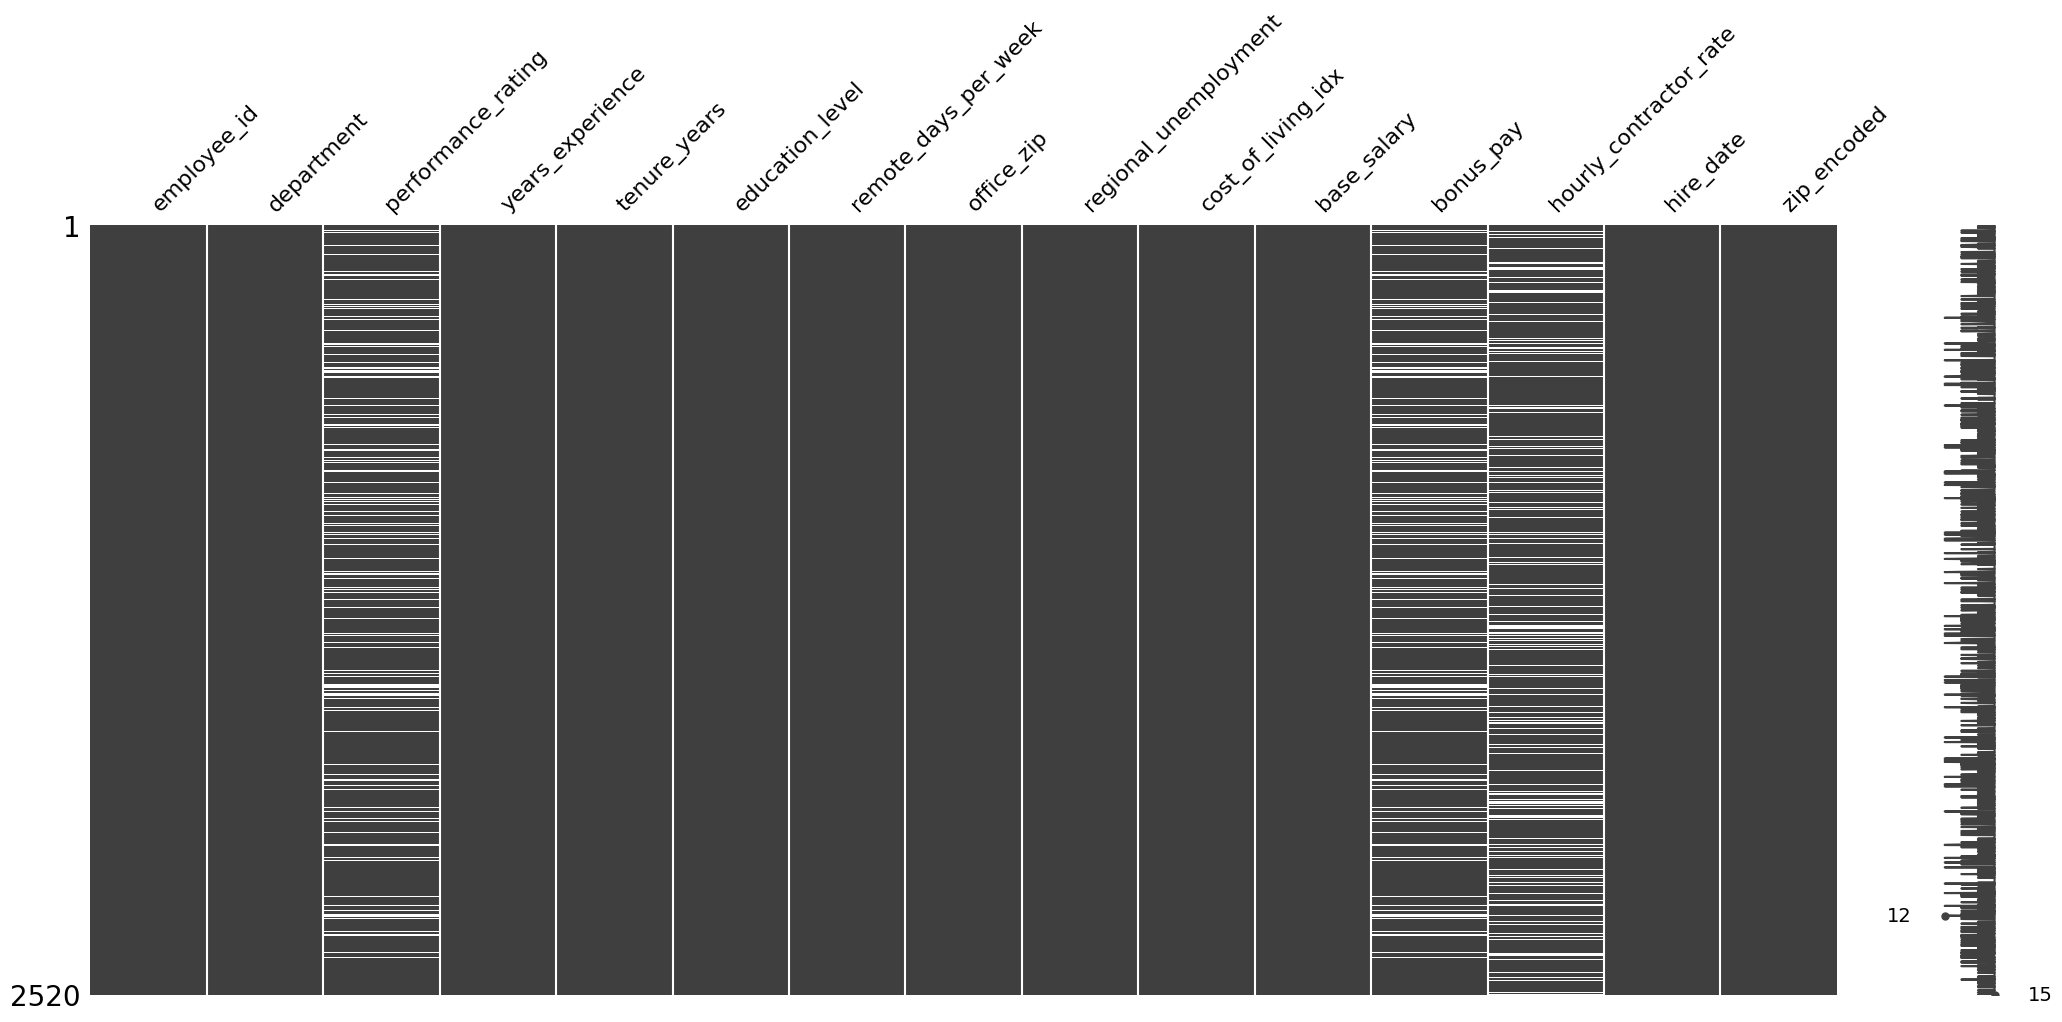

In [16]:
# Step 2: Visual Forensics of Missing Data
msno.matrix(df)

print(df.isnull().sum())

In [17]:
# Step 3: Handling the Missingness via Conditional Imputation
df['base_salary'] = df.groupby('department')['base_salary'].transform(
    lambda x: x.fillna(x.median())
)

print("Missing values in base_salary after imputation:")
print(df['base_salary'].isnull().sum())

Missing values in base_salary after imputation:
0


In [18]:
# Step 4: The Dummy Variable Trap (Intentional Failure)

dummies_trap = pd.get_dummies(df['department'], prefix='dept')
X_trap = pd.concat([df[['tenure_years']], dummies_trap], axis=1)
X_trap = X_trap.astype(float)

X_trap = sm.add_constant(X_trap)
y = df['base_salary'].astype(float)

model_trap = sm.OLS(y, X_trap).fit()
print(model_trap.summary())

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     36.41
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           5.68e-96
Time:                        18:05:01   Log-Likelihood:                -27271.
No. Observations:                2520   AIC:                         5.457e+04
Df Residuals:                    2504   BIC:                         5.467e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              6.644e+04    483.93

In [13]:
drop_first=True

In [19]:
# Step 5a: Escaping the Trap (k-1 methodology)

dummies_safe = pd.get_dummies(df['department'], prefix='dept', drop_first=True)
X_safe = pd.concat([df[['tenure_years']], dummies_safe], axis=1)
X_safe = X_safe.astype(float)

X_safe = sm.add_constant(X_safe)
y = df['base_salary'].astype(float)

model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     36.41
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           5.68e-96
Time:                        18:05:15   Log-Likelihood:                -27271.
No. Observations:                2520   AIC:                         5.457e+04
Df Residuals:                    2504   BIC:                         5.467e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              6.292e+04   1891.91

In [20]:
# Step 5b: Target Encoding High Cardinality

encoder = ce.TargetEncoder(cols=['office_zip'])
df['zip_encoded'] = encoder.fit_transform(df[['office_zip']], df['base_salary'])

print(df[['office_zip', 'zip_encoded']].head())

   office_zip   zip_encoded
0       62276  73560.698092
1       72044  73638.171755
2       50544  74905.664568
3       44520  73915.024647
4       93647  73995.250147
